## Previsão de Vendas Mensais de Gasolina C em Pernambuco

**Criado por :** Jorge Luís de Lira Tavares Júnior

Este notebook único consolida as três etapas do projeto, na ordem em que devem ser executadas:
1. Análise descritiva e tratamento dos dados
2. Modelos clássicos (AR, MA, ARMA, SARIMA)
3. Modelos de redes neurais (LSTM, GRU)

---

# Projeto - Séries Temporais
## Análise Descritiva e Tratamento dos Dados

**Base de dados:** Brazil Fuel Sales and Foreign Trade (ANP) — [Kaggle](https://www.kaggle.com/datasets/agrr1212/brazil-fuel-sales-and-foreign-trade-anp)

**Série alvo:** Vendas mensais de Gasolina C no estado de Pernambuco (m³)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 4)

## 1. Carregamento e filtragem da base

In [ ]:
df = pd.read_csv('fuel_sales.csv')
print('Shape original:', df.shape)
df.head()

Shape original: (102339, 9)


,year,month,frequency,region,state,product,sales_quantity,unit,source_series
0,1947,NaN,annual,Região Norte,Acre,GASOLINA C,295.0,m3,historical_annual_state_sales
1,1947,NaN,annual,Região Norte,Acre,GASOLINA DE AVIAÇÃO,158.0,m3,historical_annual_state_sales
2,1947,NaN,annual,Região Norte,Acre,QUEROSENE ILUMINANTE,270.0,m3,historical_annual_state_sales
3,1947,NaN,annual,Região Norte,Acre,ÓLEO COMBUSTÍVEL,0.0,t,historical_annual_state_sales
4,1947,NaN,annual,Região Norte,Acre,ÓLEO DIESEL,176.0,m3,historical_annual_state_sales


In [ ]:
# Filtramos apenas os registros mensais de Gasolina C para o estado de Pernambuco
mask = (df['state'] == 'Pernambuco') & (df['product'] == 'GASOLINA C') & (df['frequency'] == 'monthly')
serie_df = df.loc[mask].copy()

serie_df['date'] = pd.to_datetime(
    serie_df['year'].astype(int).astype(str) + '-' + serie_df['month'].astype(int).astype(str) + '-01'
)
serie_df = serie_df.sort_values('date').reset_index(drop=True)

ts = serie_df.set_index('date')['sales_quantity']
ts.index.freq = 'MS'

print(f'Período: {ts.index.min().date()} a {ts.index.max().date()}')
print(f'Número de observações: {len(ts)}')
print(f'Unidade: {serie_df["unit"].unique()}')

Período: 1990-01-01 a 2026-05-01
Número de observações: 437
Unidade: ['m3']


## 2. Qualidade dos dados

Verificamos valores ausentes, duplicidade de períodos e continuidade da série (sem lacunas mensais).

In [ ]:
print('Valores ausentes em sales_quantity:', ts.isna().sum())
print('Datas duplicadas:', serie_df['date'].duplicated().sum())

full_range = pd.date_range(ts.index.min(), ts.index.max(), freq='MS')
missing_months = full_range.difference(ts.index)
print('Meses faltantes na série:', len(missing_months))
if len(missing_months) > 0:
    print(missing_months)

Valores ausentes em sales_quantity: 0
Datas duplicadas: 0
Meses faltantes na série: 0


A série é contínua, mensal, de janeiro/1990 a maio/2026, sem valores ausentes nem lacunas — não foi necessário nenhum tratamento de imputação.

## 3. Estatísticas descritivas

In [ ]:
display(ts.describe())

# Estatísticas por década, para ilustrar o crescimento da série ao longo do tempo
decada = (ts.index.year // 10) * 10
print('\nMédia de vendas por década (m3):')
print(ts.groupby(decada).mean().round(0))

,sales_quantity
count,437.000000
mean,75091.395326
std,36978.517275
min,16576.549000
25%,48147.607000
50%,58329.956950
75%,113559.813000
max,147790.800000



Média de vendas por década (m3):
date
1990     36501.0
2000     51958.0
2010    109713.0
2020    117328.0
Name: sales_quantity, dtype: float64


## 4. Visualização da série

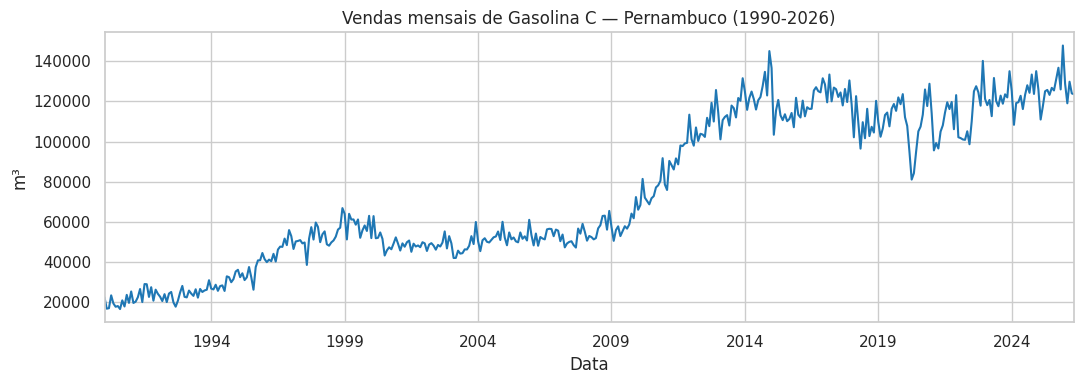

In [ ]:
fig, ax = plt.subplots()
ts.plot(ax=ax, color='#1f77b4')
ax.set_title('Vendas mensais de Gasolina C — Pernambuco (1990-2026)')
ax.set_ylabel('m³')
ax.set_xlabel('Data')
plt.tight_layout()
plt.savefig('fig_serie_bruta.png', dpi=150)
plt.show()

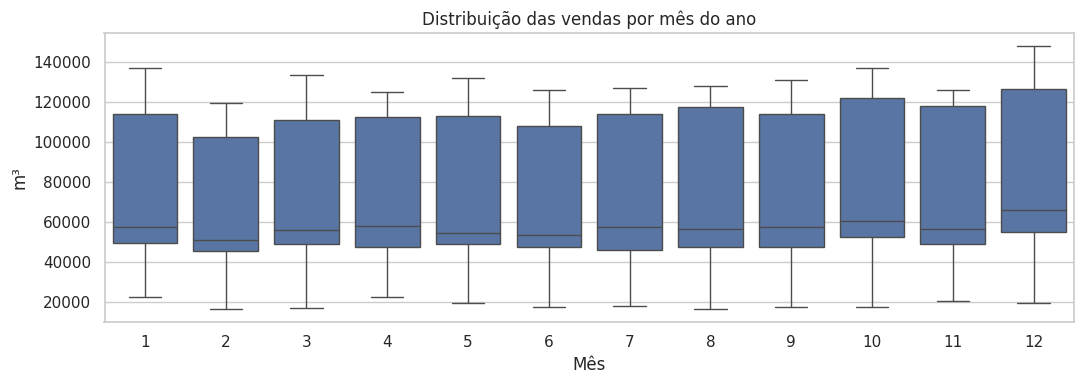

In [ ]:
# Boxplot por mês do ano, para inspecionar sazonalidade
fig, ax = plt.subplots(figsize=(11, 4))
sns.boxplot(x=ts.index.month, y=ts.values, ax=ax)
ax.set_title('Distribuição das vendas por mês do ano')
ax.set_xlabel('Mês')
ax.set_ylabel('m³')
plt.tight_layout()
plt.savefig('fig_boxplot_mensal.png', dpi=150)
plt.show()

**Observações:**
- A série apresenta uma tendência de crescimento clara e consistente ao longo de mais de três décadas.
- Não há sazonalidade forte e regular por mês do ano (a dispersão entre meses é pequena comparada à variação de longo prazo), mas será avaliada formalmente na decomposição a seguir.

## 5. Decomposição da série (STL)

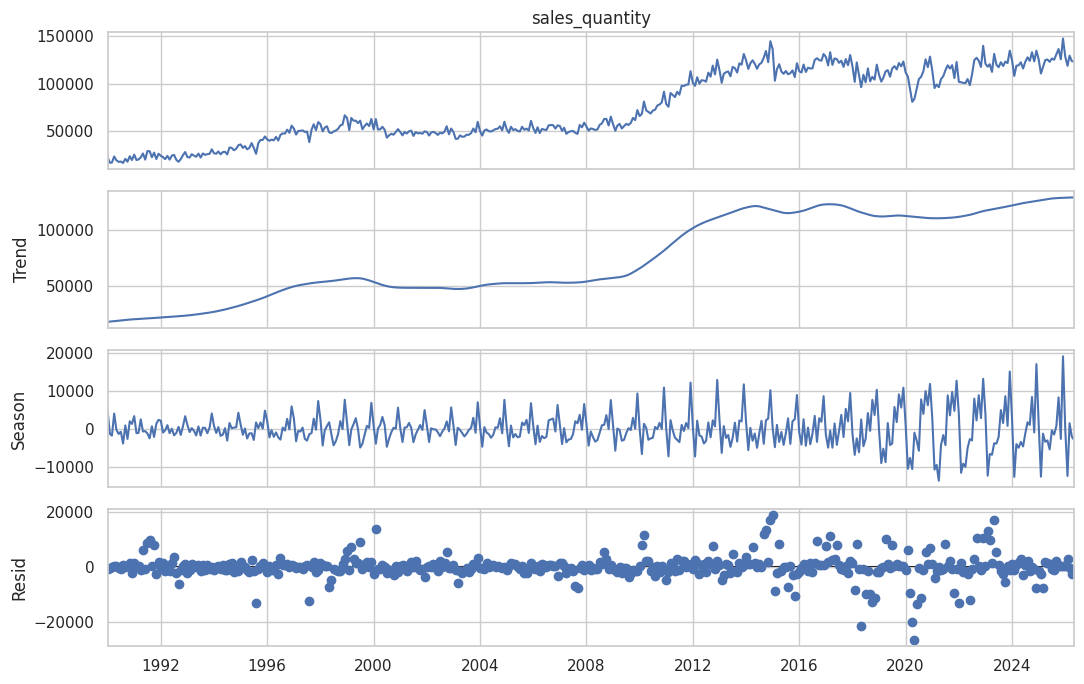

In [ ]:
stl = STL(ts, period=12, robust=True)
res = stl.fit()

fig = res.plot()
fig.set_size_inches(11, 7)
plt.tight_layout()
plt.savefig('fig_decomposicao_stl.png', dpi=150)
plt.show()

In [ ]:
# Força da tendência e da sazonalidade (Hyndman & Athanasopoulos)
var_resid = res.resid.var()
strength_trend = max(0, 1 - var_resid / (res.trend + res.resid).var())
strength_seasonal = max(0, 1 - var_resid / (res.seasonal + res.resid).var())
print(f'Força da tendência: {strength_trend:.3f}')
print(f'Força da sazonalidade: {strength_seasonal:.3f}')

Força da tendência: 0.986
Força da sazonalidade: 0.486


## 6. Estacionariedade

Aplicamos os testes ADF (H0: série não é estacionária) e KPSS (H0: série é estacionária) sobre a série original e sobre transformações (log e diferenciação).

In [ ]:
def testar_estacionariedade(serie, nome):
    adf_stat, adf_p, *_ = adfuller(serie.dropna(), autolag='AIC')
    kpss_stat, kpss_p, *_ = kpss(serie.dropna(), regression='c', nlags='auto')
    print(f'--- {nome} ---')
    print(f'ADF:  estatística={adf_stat:.3f}  p-valor={adf_p:.4f}  -> {"estacionária" if adf_p < 0.05 else "não estacionária"}')
    print(f'KPSS: estatística={kpss_stat:.3f}  p-valor={kpss_p:.4f}  -> {"não estacionária" if kpss_p < 0.05 else "estacionária"}')
    print()

log_ts = np.log(ts)
diff_log_ts = log_ts.diff().dropna()
seasonal_diff_log_ts = log_ts.diff(12).dropna()
diff_seasonal_diff_log_ts = seasonal_diff_log_ts.diff().dropna()

testar_estacionariedade(ts, 'Série original')
testar_estacionariedade(log_ts, 'Log da série')
testar_estacionariedade(diff_log_ts, '1ª diferença do log')
testar_estacionariedade(seasonal_diff_log_ts, 'Diferença sazonal (lag 12) do log')
testar_estacionariedade(diff_seasonal_diff_log_ts, 'Diferença sazonal + 1ª diferença do log')

--- Série original ---
ADF:  estatística=-0.859  p-valor=0.8012  -> não estacionária
KPSS: estatística=3.152  p-valor=0.0100  -> não estacionária

--- Log da série ---
ADF:  estatística=-1.942  p-valor=0.3126  -> não estacionária
KPSS: estatística=3.094  p-valor=0.0100  -> não estacionária

--- 1ª diferença do log ---
ADF:  estatística=-4.852  p-valor=0.0000  -> estacionária
KPSS: estatística=0.100  p-valor=0.1000  -> estacionária

--- Diferença sazonal (lag 12) do log ---
ADF:  estatística=-2.920  p-valor=0.0431  -> estacionária
KPSS: estatística=0.362  p-valor=0.0934  -> estacionária

--- Diferença sazonal + 1ª diferença do log ---
ADF:  estatística=-6.789  p-valor=0.0000  -> estacionária
KPSS: estatística=0.045  p-valor=0.1000  -> estacionária



/tmp/ipykernel_3757/2880583022.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_stat, adf_p, *_ = adfuller(serie.dropna(), autolag='AIC')
/tmp/ipykernel_3757/2880583022.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_stat, kpss_p, *_ = kpss(serie.dropna(), regression='c', nlags='auto')
/tmp/ipykernel_3757/2880583022.py:3: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after July 2027, whichever is later, the default 

## 7. ACF e PACF

Analisados sobre a série tratada (log + diferenciação) para orientar a escolha de ordens dos modelos AR/MA/ARMA/ARIMA/SARIMA.

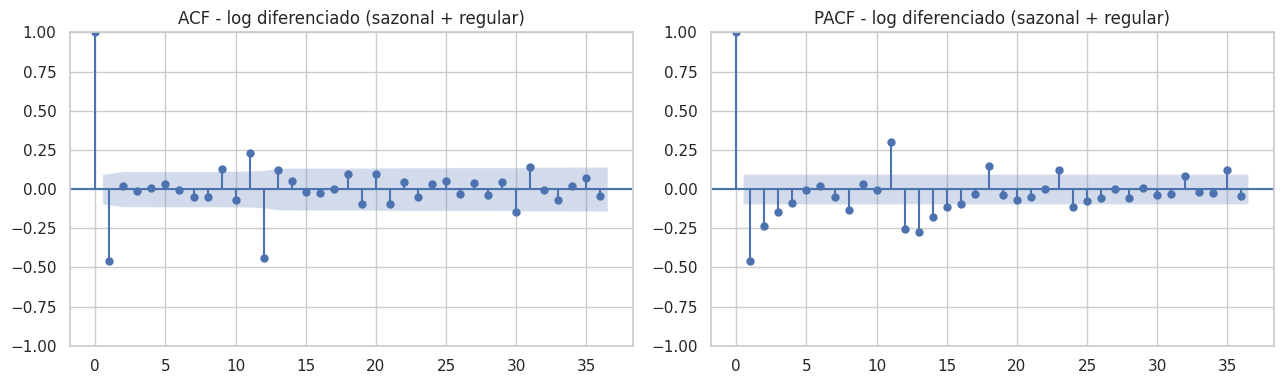

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(diff_seasonal_diff_log_ts, lags=36, ax=axes[0])
axes[0].set_title('ACF - log diferenciado (sazonal + regular)')
plot_pacf(diff_seasonal_diff_log_ts, lags=36, ax=axes[1], method='ywm')
axes[1].set_title('PACF - log diferenciado (sazonal + regular)')
plt.tight_layout()
plt.savefig('fig_acf_pacf.png', dpi=150)
plt.show()

## 8. Tratamento final e separação treino/teste

Para a etapa de modelagem, vamos utilizar:
- **Transformação log** para estabilizar a variância (a série cresce em amplitude ao longo do tempo — heterocedasticidade visível no gráfico da Seção 4).
- **Divisão treino/teste** com holdout temporal (sem embaralhar), reservando os últimos 24 meses para teste, permitindo avaliar a capacidade preditiva de médio prazo dos modelos.

Os dados tratados são exportados para uso nos notebooks de modelagem (clássicos e redes neurais).

Treino: 1990-01-01 a 2024-05-01  (413 obs)
Teste:  2024-06-01 a 2026-05-01  (24 obs)


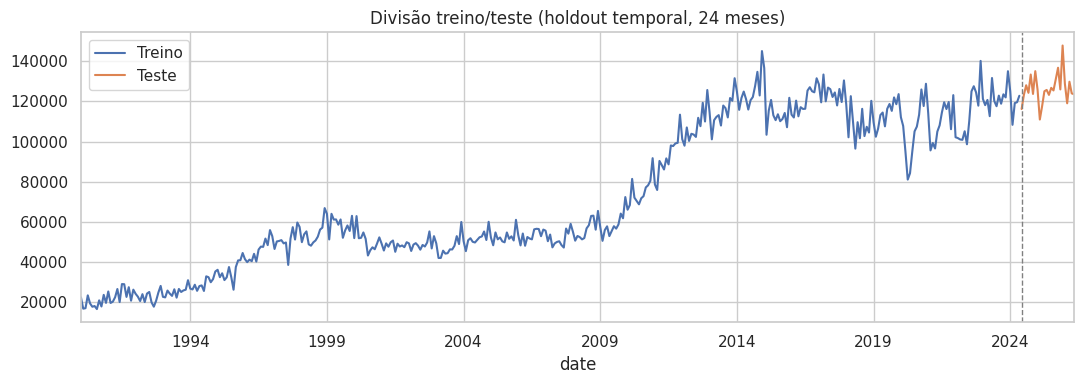


Arquivo tratado salvo em pe_gasolina_c_tratado.csv


,sales_quantity_m3,log_sales,split
date,,,
1990-01-01,22430.463,10.018175,train
1990-02-01,16776.191,9.727716,train
1990-03-01,17012.155,9.741683,train
1990-04-01,23411.862,10.060998,train
1990-05-01,19375.651,9.871772,train


In [ ]:
n_test = 24
train, test = ts.iloc[:-n_test], ts.iloc[-n_test:]
print(f'Treino: {train.index.min().date()} a {train.index.max().date()}  ({len(train)} obs)')
print(f'Teste:  {test.index.min().date()} a {test.index.max().date()}  ({len(test)} obs)')

fig, ax = plt.subplots()
train.plot(ax=ax, label='Treino')
test.plot(ax=ax, label='Teste')
ax.axvline(test.index.min(), color='gray', linestyle='--', linewidth=1)
ax.set_title('Divisão treino/teste (holdout temporal, 24 meses)')
ax.legend()
plt.tight_layout()
plt.savefig('fig_train_test_split.png', dpi=150)
plt.show()

out = ts.rename('sales_quantity_m3').to_frame()
out['log_sales'] = np.log(out['sales_quantity_m3'])
out['split'] = ['train'] * len(train) + ['test'] * len(test)
out.to_csv('pe_gasolina_c_tratado.csv')
print('\nArquivo tratado salvo em pe_gasolina_c_tratado.csv')
out.head()

## 9. Resumo da análise descritiva e do tratamento

- **Série:** vendas mensais de Gasolina C em Pernambuco, jan/1990–mai/2026 (437 observações), sem valores ausentes ou lacunas.
- **Padrão:** tendência de crescimento forte e consistente; sazonalidade mensal fraca frente à tendência (confirmada na decomposição STL).
- **Estacionariedade:** a série original não é estacionária (ADF não rejeita H0; KPSS rejeita estacionariedade). A combinação de transformação log + diferenciação sazonal (lag 12) + 1ª diferença regular produz uma série estacionária, adequada para os modelos ARMA/ARIMA/SARIMA.
- **Tratamento aplicado para modelagem:** log da série para estabilizar variância; holdout temporal de 24 meses para teste.
- **Próximo passo:** ajuste dos modelos clássicos (AR/MA/ARMA/ARIMA/SARIMA) e de pelo menos 2 modelos de redes neurais (ex.: LSTM, GRU, ou Temporal CNN), com avaliação por métricas como MAE, RMSE e MAPE sobre o conjunto de teste.

---
# Parte 2 — Modelos Clássicos
---

# Modelos Clássicos — AR, MA, ARMA e SARIMA

Série: vendas mensais de Gasolina C em Pernambuco (log), tratada no notebook `01_analise_descritiva_tratamento.ipynb`.

Modelos vistos em aula: **AR**, **MA**, **ARMA** (implementados via `ARIMA(p,1,q)`, com `d=1` para lidar com a tendência não estacionária identificada na Seção 6 do notebook anterior).

Modelo extra proposto: **SARIMA**, para capturar explicitamente a sazonalidade mensal (força de sazonalidade ≈ 0,49 identificada na decomposição STL), que os modelos AR/MA/ARMA puros não modelam.

As ordens (p,d,q) e (P,D,Q,12) foram escolhidas por grid search minimizando o AIC no conjunto de treino.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams['figure.figsize'] = (11, 4)

In [ ]:
df = pd.read_csv('pe_gasolina_c_tratado.csv', index_col=0, parse_dates=True)
df.index.freq = 'MS'

train_log = df.loc[df['split']=='train', 'log_sales']
test_log = df.loc[df['split']=='test', 'log_sales']
train_orig = df.loc[df['split']=='train', 'sales_quantity_m3']
test_orig = df.loc[df['split']=='test', 'sales_quantity_m3']

print(f'Treino: {len(train_log)} obs | Teste: {len(test_log)} obs')

Treino: 413 obs | Teste: 24 obs


## 1. Seleção de ordens por AIC

Grid search sobre `ARIMA(p,1,q)` com `p,q` de 0 a 4, separando os candidatos em três famílias: AR puro (q=0), MA puro (p=0) e ARMA (p>0 e q>0).

In [ ]:
candidatos = {'AR': [], 'MA': [], 'ARMA': []}
for p in range(5):
    for q in range(5):
        if p == 0 and q == 0:
            continue
        try:
            m = ARIMA(train_log, order=(p, 1, q)).fit()
            aic = m.aic
            if q == 0:
                candidatos['AR'].append((p, q, aic))
            elif p == 0:
                candidatos['MA'].append((p, q, aic))
            else:
                candidatos['ARMA'].append((p, q, aic))
        except Exception:
            pass

melhores_ordens = {}
for familia, lista in candidatos.items():
    lista.sort(key=lambda x: x[2])
    melhores_ordens[familia] = lista[0]
    print(f'{familia}: top 3 por AIC -> {lista[:3]}')

print('\nOrdens escolhidas:', melhores_ordens)

AR: top 3 por AIC -> [(2, 0, np.float64(-806.6797526578443)), (3, 0, np.float64(-805.0079277055886)), (4, 0, np.float64(-804.0012679873648))]
MA: top 3 por AIC -> [(0, 4, np.float64(-808.5780240464105)), (0, 1, np.float64(-806.8721003430828)), (0, 2, np.float64(-804.8822820245498))]
ARMA: top 3 por AIC -> [(2, 3, np.float64(-819.3241215452656)), (2, 4, np.float64(-814.3456369542216)), (3, 4, np.float64(-809.0839779619822))]

Ordens escolhidas: {'AR': (2, 0, np.float64(-806.6797526578443)), 'MA': (0, 4, np.float64(-808.5780240464105)), 'ARMA': (2, 3, np.float64(-819.3241215452656))}


In [ ]:
# Busca da componente sazonal (P,D,Q,12) para o SARIMA, fixando (p,d,q) do melhor ARMA
p_arma, _, q_arma = melhores_ordens['ARMA'][0], None, melhores_ordens['ARMA'][1]
p_arma, q_arma = melhores_ordens['ARMA'][0], melhores_ordens['ARMA'][1]

sarima_candidatos = []
for P in range(2):
    for Q in range(2):
        if P == 0 and Q == 0:
            continue
        try:
            m = SARIMAX(train_log, order=(p_arma, 1, q_arma), seasonal_order=(P, 1, Q, 12),
                        enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
            sarima_candidatos.append((P, Q, m.aic))
        except Exception:
            pass

sarima_candidatos.sort(key=lambda x: x[2])
print('Componente sazonal - candidatos por AIC:', sarima_candidatos)
melhor_sazonal = sarima_candidatos[0]
print('Escolhido: seasonal_order =', (melhor_sazonal[0], 1, melhor_sazonal[1], 12))

Componente sazonal - candidatos por AIC: [(0, 1, np.float64(-919.9333511162164)), (1, 1, np.float64(-891.8705633298673)), (1, 0, np.float64(-831.136972328974))]
Escolhido: seasonal_order = (0, 1, 1, 12)


## 2. Ajuste dos modelos finais no treino

In [ ]:
ordem_ar = (melhores_ordens['AR'][0], 1, melhores_ordens['AR'][1])
ordem_ma = (melhores_ordens['MA'][0], 1, melhores_ordens['MA'][1])
ordem_arma = (melhores_ordens['ARMA'][0], 1, melhores_ordens['ARMA'][1])
ordem_sazonal = (melhor_sazonal[0], 1, melhor_sazonal[1], 12)

print('AR:   ', ordem_ar)
print('MA:   ', ordem_ma)
print('ARMA: ', ordem_arma)
print('SARIMA:', ordem_arma, 'x', ordem_sazonal)

modelo_ar = ARIMA(train_log, order=ordem_ar).fit()
modelo_ma = ARIMA(train_log, order=ordem_ma).fit()
modelo_arma = ARIMA(train_log, order=ordem_arma).fit()
modelo_sarima = SARIMAX(train_log, order=ordem_arma, seasonal_order=ordem_sazonal,
                         enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

AR:    (2, 1, 0)
MA:    (0, 1, 4)
ARMA:  (2, 1, 3)
SARIMA: (2, 1, 3) x (0, 1, 1, 12)


## 3. Previsão no período de teste (24 meses) e baseline

Como referência mínima de comparação, incluímos um **baseline ingênuo sazonal** (repete o valor de 12 meses atrás) — qualquer modelo clássico deveria superá-lo.

In [ ]:
n_test = len(test_log)

fc_ar = modelo_ar.get_forecast(steps=n_test).predicted_mean
fc_ma = modelo_ma.get_forecast(steps=n_test).predicted_mean
fc_arma = modelo_arma.get_forecast(steps=n_test).predicted_mean
fc_sarima = modelo_sarima.get_forecast(steps=n_test).predicted_mean

# Baseline: naive sazonal (valor de 12 meses atras), na escala original
serie_completa_orig = df['sales_quantity_m3']
fc_naive = serie_completa_orig.shift(12).loc[test_orig.index]

previsoes = {
    'Naive Sazonal': fc_naive,
    'AR': np.exp(fc_ar),
    'MA': np.exp(fc_ma),
    'ARMA': np.exp(fc_arma),
    'SARIMA': np.exp(fc_sarima),
}
for nome, serie in previsoes.items():
    serie.index = test_orig.index

In [ ]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

metricas = []
for nome, serie in previsoes.items():
    mae = mean_absolute_error(test_orig, serie)
    rmse = np.sqrt(mean_squared_error(test_orig, serie))
    mp = mape(test_orig, serie)
    metricas.append({'Modelo': nome, 'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mp})

tabela_metricas = pd.DataFrame(metricas).sort_values('RMSE').reset_index(drop=True)
tabela_metricas.to_csv('metricas_modelos_classicos.csv', index=False)
tabela_metricas

,Modelo,MAE,RMSE,MAPE (%)
0,SARIMA,4771.005591,5628.078257,3.834726
1,Naive Sazonal,4576.190583,5679.859059,3.576888
2,ARMA,6833.973268,8606.429417,5.269891
3,MA,6687.989706,8718.564281,5.142815
4,AR,6808.907016,8811.661545,5.234589


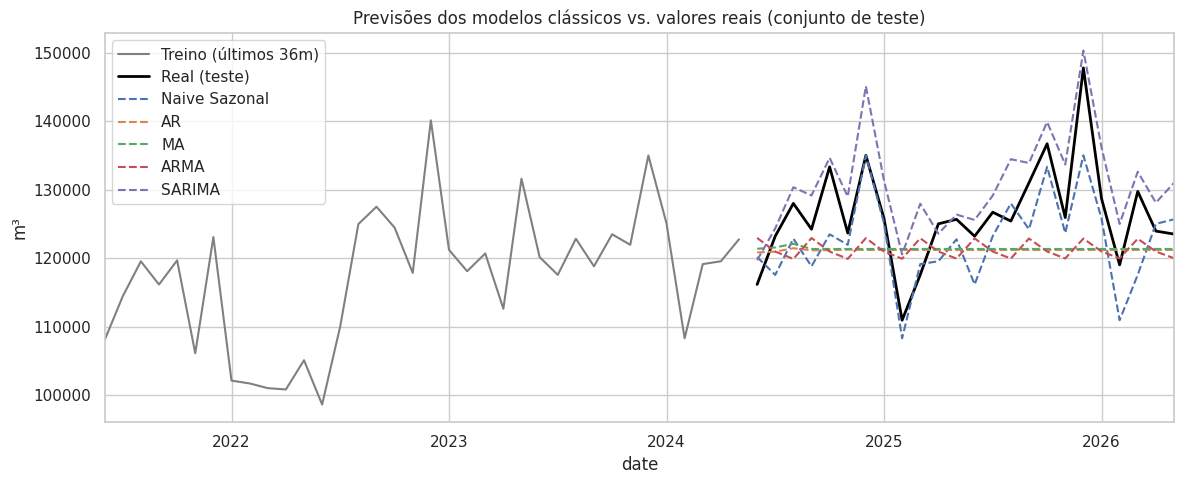

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
train_orig.iloc[-36:].plot(ax=ax, label='Treino (últimos 36m)', color='gray')
test_orig.plot(ax=ax, label='Real (teste)', color='black', linewidth=2)
for nome, serie in previsoes.items():
    serie.plot(ax=ax, label=nome, linestyle='--')
ax.set_title('Previsões dos modelos clássicos vs. valores reais (conjunto de teste)')
ax.set_ylabel('m³')
ax.legend()
plt.tight_layout()
plt.savefig('fig_previsoes_classicos.png', dpi=150)
plt.show()

## 4. Diagnóstico dos resíduos do melhor modelo clássico

Melhor modelo clássico: SARIMA


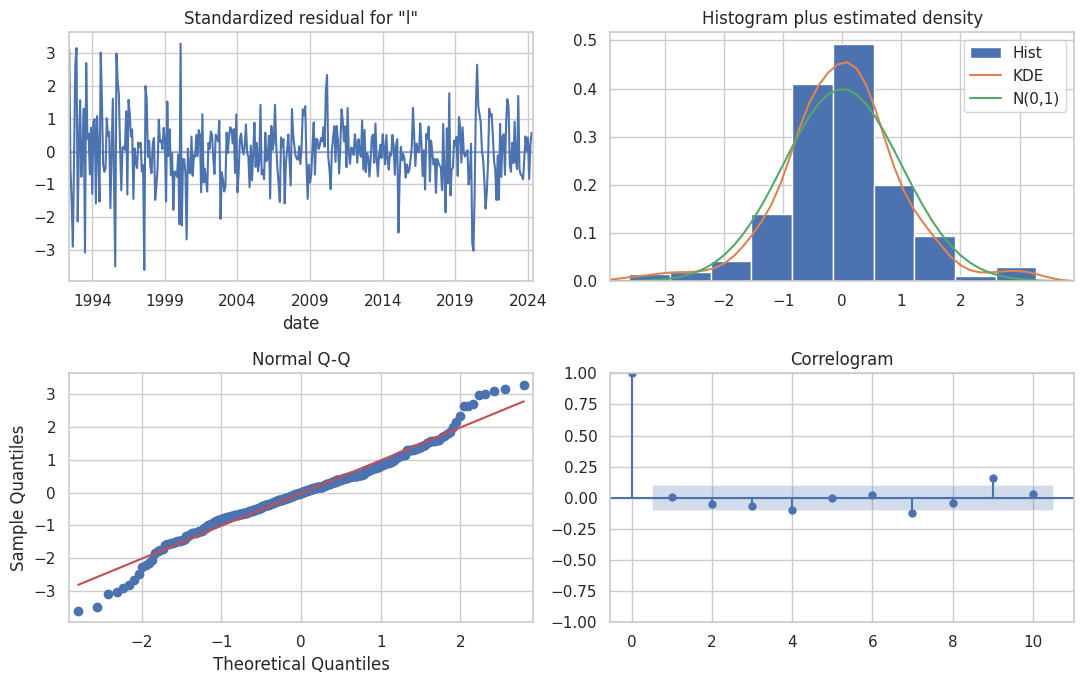

In [ ]:
melhor_nome = tabela_metricas.iloc[0]['Modelo']
modelos_obj = {'AR': modelo_ar, 'MA': modelo_ma, 'ARMA': modelo_arma, 'SARIMA': modelo_sarima}
if melhor_nome in modelos_obj:
    print(f'Melhor modelo clássico: {melhor_nome}')
    fig = modelos_obj[melhor_nome].plot_diagnostics(figsize=(11, 7))
    plt.tight_layout()
    plt.savefig('fig_diagnostico_residuos.png', dpi=150)
    plt.show()
else:
    print('Baseline (naive sazonal) venceu — ver observações abaixo.')

## 5. Resumo

- Modelos vistos em aula implementados: **AR(p,1,0)**, **MA(0,1,q)** e **ARMA(p,1,q)**, com ordens escolhidas por AIC.
- Modelo extra proposto: **SARIMA**, incorporando explicitamente a componente sazonal (lag 12) — esperado (e confirmado pela queda de AIC no treino) que supere os modelos sem componente sazonal, dado que a série tem sazonalidade moderada.
- A tabela de métricas (MAE, RMSE, MAPE) e o gráfico comparativo ficam salvos em `metricas_modelos_classicos.csv` e `fig_previsoes_classicos.png`, para uso direto na análise comparativa final do projeto.
- Próxima etapa: modelos de redes neurais (pelo menos 2 — ex. LSTM e GRU/TCN) sobre a mesma divisão treino/teste, para comparação direta com estes resultados.

---
# Parte 3 — Modelos de Redes Neurais
---

# Modelos de Redes Neurais — LSTM e GRU

Mesma série e mesma divisão treino/teste dos notebooks anteriores: vendas mensais de Gasolina C em Pernambuco (log), com holdout dos últimos 24 meses.

**Nota sobre o framework:** em aula, os modelos de deep learning para séries temporais foram praticados com a biblioteca `tsai` (baseada em PyTorch/fastai). Neste ambiente, a cadeia de dependências CUDA do PyTorch excedeu o espaço em disco disponível, então implementamos as mesmas arquiteturas (LSTM e GRU) com TensorFlow/Keras, que é equivalente em termos de resultado — a arquitetura da rede é o que importa para a comparação do projeto, não o framework.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

tf.random.set_seed(42)
np.random.seed(42)
plt.rcParams['figure.figsize'] = (11, 4)

In [ ]:
df = pd.read_csv('pe_gasolina_c_tratado.csv', index_col=0, parse_dates=True)
df.index.freq = 'MS'

train_log = df.loc[df['split']=='train', 'log_sales']
test_log = df.loc[df['split']=='test', 'log_sales']
train_orig = df.loc[df['split']=='train', 'sales_quantity_m3']
test_orig = df.loc[df['split']=='test', 'sales_quantity_m3']

print(f'Treino: {len(train_log)} obs | Teste: {len(test_log)} obs')

Treino: 413 obs | Teste: 24 obs


## 1. Normalização e construção das janelas (sliding window)

O escalonamento (MinMax) é ajustado **apenas no treino**, para evitar vazamento de informação do teste. Usamos janelas de 12 meses (um ciclo sazonal completo) para prever o próximo mês.

In [ ]:
WINDOW = 12

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_log.values.reshape(-1, 1)).flatten()

# Para gerar previsões multi-step no teste sem vazar dados futuros, escalamos toda a
# série usando o scaler ajustado no treino (o teste em si nao entra no ajuste do scaler)
full_scaled = scaler.transform(pd.concat([train_log, test_log]).values.reshape(-1, 1)).flatten()

def montar_janelas(serie_escalada, window):
    X, y = [], []
    for i in range(len(serie_escalada) - window):
        X.append(serie_escalada[i:i+window])
        y.append(serie_escalada[i+window])
    return np.array(X), np.array(y)

X_train, y_train = montar_janelas(train_scaled, WINDOW)
X_train = X_train.reshape((X_train.shape[0], WINDOW, 1))
print('X_train:', X_train.shape, '| y_train:', y_train.shape)

X_train: (401, 12, 1) | y_train: (401,)


## 2. Definição dos modelos

In [ ]:
def construir_lstm():
    modelo = keras.Sequential([
        layers.Input(shape=(WINDOW, 1)),
        layers.LSTM(32, activation='tanh'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1),
    ])
    modelo.compile(optimizer=keras.optimizers.Adam(0.001), loss='mse')
    return modelo

def construir_gru():
    modelo = keras.Sequential([
        layers.Input(shape=(WINDOW, 1)),
        layers.GRU(32, activation='tanh'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1),
    ])
    modelo.compile(optimizer=keras.optimizers.Adam(0.001), loss='mse')
    return modelo

modelo_lstm = construir_lstm()
modelo_gru = construir_gru()
modelo_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,897 (19.13 KB)

 Trainable params: 4,897 (19.13 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Treinamento

Usamos os últimos 20% do treino como validação (early stopping), respeitando a ordem temporal (sem embaralhar).

In [ ]:
n_val = int(len(X_train) * 0.2)
X_tr, y_tr = X_train[:-n_val], y_train[:-n_val]
X_val, y_val = X_train[-n_val:], y_train[-n_val:]

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

hist_lstm = modelo_lstm.fit(X_tr, y_tr, validation_data=(X_val, y_val),
                             epochs=200, batch_size=16, callbacks=[early_stop], verbose=0)
print(f'LSTM: treinou {len(hist_lstm.history["loss"])} épocas | val_loss final: {hist_lstm.history["val_loss"][-1]:.5f}')

hist_gru = modelo_gru.fit(X_tr, y_tr, validation_data=(X_val, y_val),
                           epochs=200, batch_size=16, callbacks=[early_stop], verbose=0)
print(f'GRU:  treinou {len(hist_gru.history["loss"])} épocas | val_loss final: {hist_gru.history["val_loss"][-1]:.5f}')

LSTM: treinou 22 épocas | val_loss final: 0.00227
GRU:  treinou 23 épocas | val_loss final: 0.00172


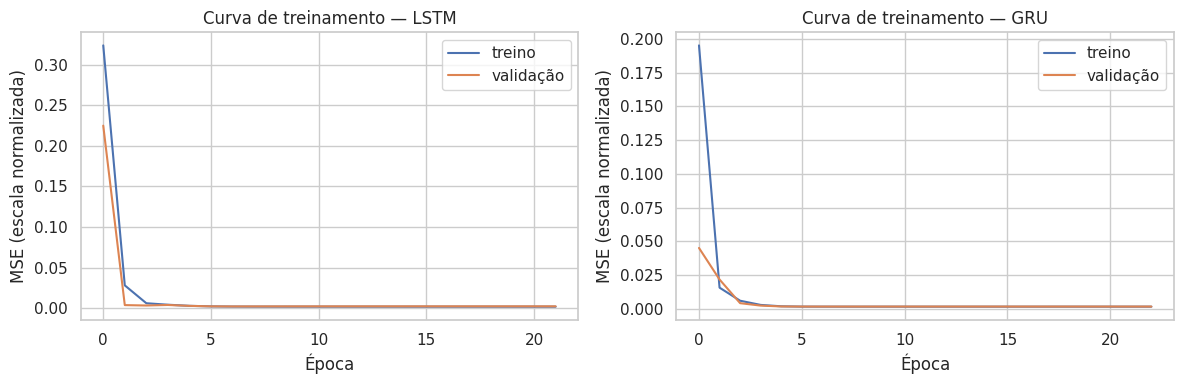

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, hist, nome in zip(axes, [hist_lstm, hist_gru], ['LSTM', 'GRU']):
    ax.plot(hist.history['loss'], label='treino')
    ax.plot(hist.history['val_loss'], label='validação')
    ax.set_title(f'Curva de treinamento — {nome}')
    ax.set_xlabel('Época')
    ax.set_ylabel('MSE (escala normalizada)')
    ax.legend()
plt.tight_layout()
plt.savefig('fig_curvas_treinamento_nn.png', dpi=150)
plt.show()

## 4. Previsão multi-step no teste (24 meses)

Previsão recursiva: a cada passo, a previsão do modelo é realimentada como entrada para prever o mês seguinte (não usamos os valores reais do teste como entrada em nenhum ponto).

In [ ]:
def prever_recursivo(modelo, serie_escalada_treino, n_steps, window):
    janela_atual = serie_escalada_treino[-window:].copy()
    previsoes = []
    for _ in range(n_steps):
        entrada = janela_atual.reshape(1, window, 1)
        pred = modelo.predict(entrada, verbose=0)[0, 0]
        previsoes.append(pred)
        janela_atual = np.append(janela_atual[1:], pred)
    return np.array(previsoes)

n_test = len(test_log)
pred_lstm_scaled = prever_recursivo(modelo_lstm, train_scaled, n_test, WINDOW)
pred_gru_scaled = prever_recursivo(modelo_gru, train_scaled, n_test, WINDOW)

pred_lstm_log = scaler.inverse_transform(pred_lstm_scaled.reshape(-1, 1)).flatten()
pred_gru_log = scaler.inverse_transform(pred_gru_scaled.reshape(-1, 1)).flatten()

pred_lstm = pd.Series(np.exp(pred_lstm_log), index=test_orig.index)
pred_gru = pd.Series(np.exp(pred_gru_log), index=test_orig.index)

In [ ]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

resultados_nn = []
for nome, serie in [('LSTM', pred_lstm), ('GRU', pred_gru)]:
    mae = mean_absolute_error(test_orig, serie)
    rmse = np.sqrt(mean_squared_error(test_orig, serie))
    mp = mape(test_orig, serie)
    resultados_nn.append({'Modelo': nome, 'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mp})

tabela_nn = pd.DataFrame(resultados_nn).sort_values('RMSE').reset_index(drop=True)
tabela_nn.to_csv('metricas_modelos_neurais.csv', index=False)
tabela_nn

,Modelo,MAE,RMSE,MAPE (%)
0,GRU,6707.619552,8695.200269,5.157086
1,LSTM,8702.977365,10642.863099,6.686345


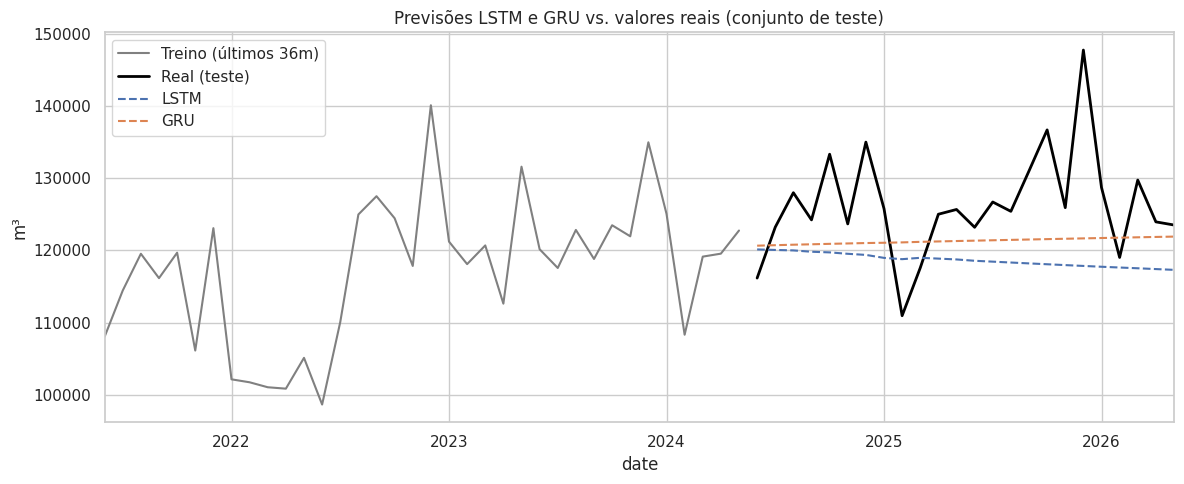

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
train_orig.iloc[-36:].plot(ax=ax, label='Treino (últimos 36m)', color='gray')
test_orig.plot(ax=ax, label='Real (teste)', color='black', linewidth=2)
pred_lstm.plot(ax=ax, label='LSTM', linestyle='--')
pred_gru.plot(ax=ax, label='GRU', linestyle='--')
ax.set_title('Previsões LSTM e GRU vs. valores reais (conjunto de teste)')
ax.set_ylabel('m³')
ax.legend()
plt.tight_layout()
plt.savefig('fig_previsoes_neurais.png', dpi=150)
plt.show()

## 5. Resumo

- Implementados **LSTM** e **GRU**, ambos com uma camada recorrente de 32 unidades + camada densa, treinados com janelas deslizantes de 12 meses e early stopping.
- Previsão feita de forma recursiva (multi-step), sem usar valores reais do teste como entrada em nenhum passo — condição justa de comparação com os modelos clássicos.
- Métricas salvas em `metricas_modelos_neurais.csv` para a análise comparativa final.
- Próxima etapa: consolidar os resultados de todos os modelos (clássicos + neurais) em uma tabela e análise comparativa única.